# GP Training

$$
\text{GP} = \{R\ |\ T_{H,1},\ T_{S,1},\ u_1\}
$$

---

## Setup

In [1]:
import os
dir = os.path.abspath('')  # directory of notebook
import sys
sys.path.append(os.path.join(dir, '..', '..'))  # package directory
from src.FoKL import FoKLRoutines
import pandas as pd
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.interpolate import interp1d

In [2]:
# modelname = "tclab_residual_withZeros"
modelname = "tclab_residual_withZeros_stepTests2"
BUFFER_ZEROS = True  # boolean to add instances of R=0 at (Th1,Ts1,u1)=(0,0,0)

In [3]:
# data = pd.read_csv(os.path.join(dir, "data", "step_tests.csv"))
data = pd.read_csv(os.path.join(dir, "data", "step_tests2.csv"))
alpha = 0.00016 # watts / (units P1 * percent U1)
P1 = 200 # P1 units

tvec = data["Time"].values
Ts1 = data["T1"].values - data["T1"][0]  # minus Tamb
u1 = data["Q1"].values

## Linear Regression:

- see https://dowlinglab.github.io/pyomo-doe/notebooks/numpy_simulation.html

In [4]:
import matplotlib.pyplot as plt

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE)  # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)  # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)  # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rc('lines', linewidth=3)

In [5]:
# Initial point:
param0 = [0.05,  # Ua, watts/deg C
          0.05,  # Ub, watts/deg C
        #   1 / 5,     # 1/CpH, 1/(joules/deg C)
          5,     # CpH, joules/deg C
        #   1 / 1]     # 1/CpS, 1/(joules/deg C)
          1]     # CpS, joules/deg C

# Solve model:

u1_interp = interp1d(tvec, u1, kind='previous')

def tclab_model(param):
    # Ua, Ub, inv_CpH, inv_CpS = param  # adjustable parameters
    Ua, Ub, CpH, CpS = param  # adjustable parameters

    def deriv(t, y):  # two-state model
        T1H, T1S = y
        # dT1H = (-Ua * T1H + Ub * (T1S - T1H) + alpha * P1 * u1_interp(t)) * inv_CpH
        dT1H = (-Ua * T1H + Ub * (T1S - T1H) + alpha * P1 * u1_interp(t)) / CpH
        # dT1S = Ub * (T1H - T1S) * inv_CpS
        dT1S = Ub * (T1H - T1S) / CpS
        return [dT1H, dT1S]
    
    soln = solve_ivp(deriv, [tvec[0], tvec[-1]], [0, 0], t_eval=tvec)  # model solution
    
    pred = pd.DataFrame()  # dataframe with predictions
    pred["Time"] = tvec
    pred["TH1"] = soln.y[0]
    pred["TS1"] = soln.y[1]
    pred["Q1"] = u1_interp(tvec)

    return pred

# Regress model
def residuals(param):
    pred = tclab_model(param)
    return pred["TS1"] - Ts1

# Set bounds (non-negative):
bnds = ([0.0, 0.0, 0.0, 0.0], [np.inf, np.inf, np.inf, np.inf])

# Perform least squares nonlinear regression:
nl_results = least_squares(residuals, param0, bounds=bnds, method='trf', verbose=2, loss="arctan")
param = nl_results.x

# ========================================

# Ua, Ub, inv_CpH, inv_CpS = param
# CpH = 1 / inv_CpH
# CpS = 1 / inv_CpS

Ua, Ub, CpH, CpS = param

Ts1_p = tclab_model(param)["TS1"].values
Th1_p = tclab_model(param)["TH1"].values

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.4712e+03                                    1.61e+05    
       1              4         1.9635e+03      5.08e+02       1.13e-02       9.64e+03    
       2              5         1.7618e+03      2.02e+02       8.23e-03       1.40e+04    
       3              6         1.7598e+03      2.07e+00       2.20e-02       1.54e+04    
       4              7         1.7467e+03      1.30e+01       1.74e-03       1.35e+04    
       5             12         1.7463e+03      4.39e-01       1.43e-06       1.35e+04    
       6             14         1.7461e+03      2.20e-01       7.14e-07       1.36e+04    
       7             15         1.7456e+03      4.40e-01       1.43e-06       1.36e+04    
       8             18         1.7456e+03      5.50e-02       1.78e-07       1.36e+04    
       9             19         1.7455e+03      1.10e-01       3.57e-07       1.36e+04    

In [6]:
print(f"Ua  = {Ua}\nUb  = {Ub}\nCpH = {CpH}\nCpS = {CpS}")

Ua  = 0.06545917265884096
Ub  = 0.04041517897421771
CpH = 5.008339044183224
CpS = 1.028939326162354


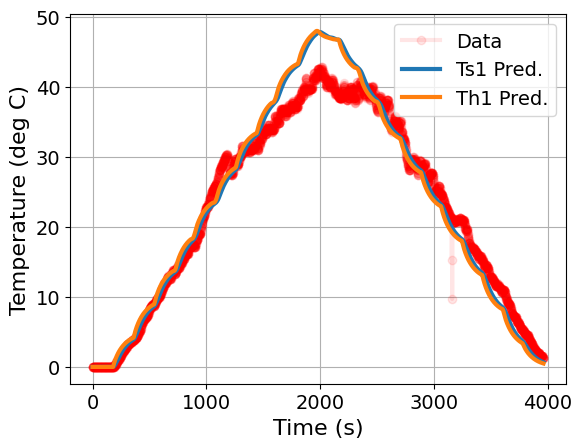

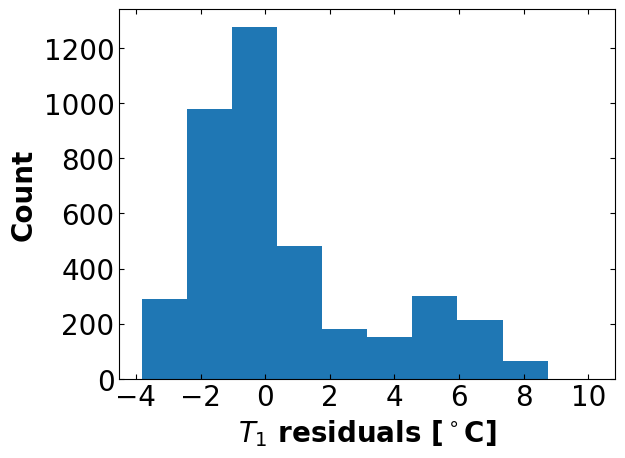

Estimated standard deviation of residuals: 2.82 deg C

Covariance of p = [Ua, Ub, inv_CpH, inv_CpS]
[[ 4.18936896e-07 -1.41496453e-05  1.05527105e-03 -5.92975779e-04]
 [-1.41496453e-05  7.55546651e-04 -4.41899443e-02  2.96626537e-02]
 [ 1.05527105e-03 -4.41899443e-02  3.54184361e+00 -1.89970596e+00]
 [-5.92975779e-04  2.96626537e-02 -1.89970596e+00  1.19298063e+00]]

Correlation matrix
[[ 1.         -0.79531762  0.8663134  -0.83877592]
 [-0.79531762  1.         -0.85423649  0.98801301]
 [ 0.8663134  -0.85423649  1.         -0.92417667]
 [-0.83877592  0.98801301 -0.92417667  1.        ]]


In [7]:
def covariance_to_correlation(cov):
    '''Convert covariance matrix into correlation matrix

    Argument:
        cov: covariance matrix

    Returns:
        cor: correlation matrix

    '''

    # Copy matrix
    cor = cov.copy()

    # Get number of rows
    n = cor.shape[0]

    # Loop over rows
    for r in range(n):
        # Loop over columns
        for c in range(n):
            # Scale element
            cor[r, c] = cor[r, c] / np.sqrt(cov[r, r] * cov[c, c])

    return cor


plt.plot(tvec, Ts1, marker='o', color='red', alpha=0.1)
plt.plot(tvec, Ts1_p, linewidth=3)
plt.plot(tvec, Th1_p, linewidth=3)
plt.xlabel("Time (s)")
plt.ylabel("Temperature (deg C)")
plt.legend(["Data", "Ts1 Pred.", "Th1 Pred."])
plt.grid()
plt.show()

# plot the residuals
r = residuals(nl_results.x)

# define font size
fs = 20

# plot data
plt.hist(r)
plt.xlabel("$T_1$ residuals [$^\circ{}$C]", fontsize=fs, fontweight='bold')
plt.ylabel("Count", fontsize=fs, fontweight='bold')

# define tick size
plt.xticks(fontsize=fs)
plt.yticks(fontsize=fs)
plt.tick_params(direction="in", top=True, right=True)

# finish plot
plt.show()

# Estimate covariance and correlation of fitted parameters

# Estimate covariance of residuals
var_residuals = r.T @ r / (len(r) - len(nl_results.x))
print(
    "Estimated standard deviation of residuals:",
    round(np.sqrt(var_residuals), 3),
    "deg C",
)

# Estimate covariance of fitted parameters
cov_p = var_residuals * np.linalg.inv(nl_results.jac.T @ nl_results.jac)

print("\nCovariance of p = [Ua, Ub, inv_CpH, inv_CpS]")
print(cov_p)

print("\nCorrelation matrix")
print(covariance_to_correlation(cov_p))

## FoKL Model

In [8]:
# Residual:
R = Ts1 - Ts1_p

# Add buffer:
buffer = 500  # number of instances added to help GP nail R=0 at (Th1,Ts1,u1)=(0,0,0)

# Train GP on two-state model predictions (i.e., un-corrected Th1, Ts1) and measured u1:
pathname = os.path.join(dir, "models", modelname)
try:
    GP = FoKLRoutines.load(pathname)
    print("Model already trained. Rename 'modelname' to train a new model.")
except Exception as exception:
    GP = FoKLRoutines.FoKL(kernel=1, UserWarnings=False, aic=True, way3=True)
    pillow=[[0.01, 0.05], [0.01, 0.05], [0, 0]]

    if BUFFER_ZEROS:
        GP.fit([np.concatenate([np.zeros(buffer), Th1_p]), 
                np.concatenate([np.zeros(buffer), Ts1_p]), 
                np.concatenate([np.zeros(buffer), u1])], 
                np.concatenate([np.zeros(buffer), R]), 
                clean=True, pillow=pillow)
    else:
        GP.fit([Th1_p, Ts1_p, u1], R, clean=True, pillow=pillow)
    
    GP.save(pathname)

Model already trained. Rename 'modelname' to train a new model.


# NOTES

- *tclab_optimization.ipynb* found the Pyomo model with the GP correction only works if ```CpH, CpS``` are found directly in the linear regression instead of ```inv_CpH, inv_CpS```; it is not understood why
- ```pillow=[[0.01, 0.05], [0.01, 0.05], [0, 0]]``` works though others may work too

# Surface plots to view GP "resonances" which if left unbounded cause non-physical Pyomo solution

interactive(children=(IntSlider(value=50, description='u', step=5), Output()), _dom_classes=('widget-interact'…

<function __main__.graph(u)>

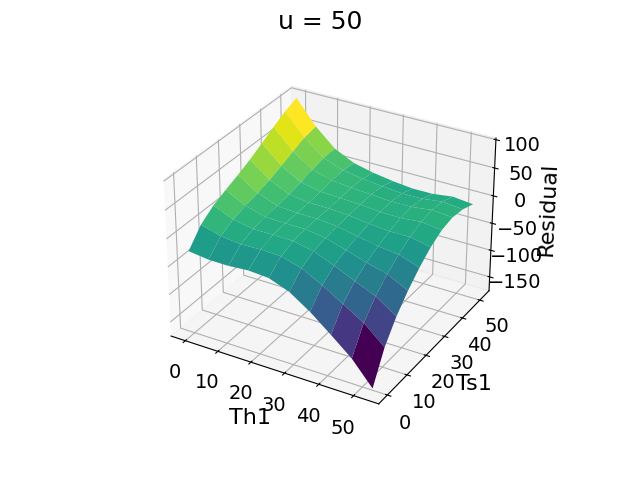

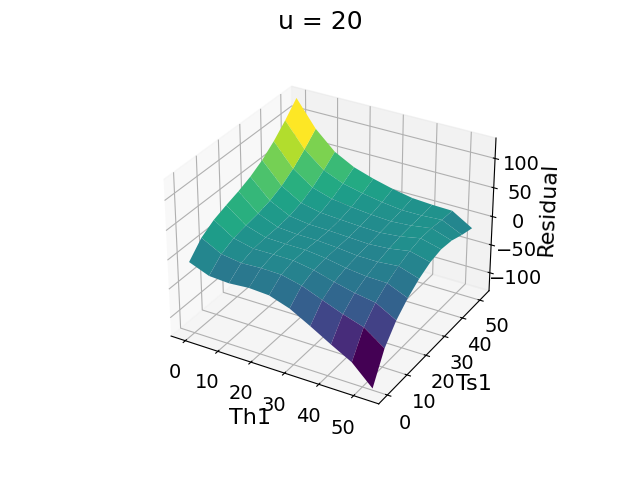

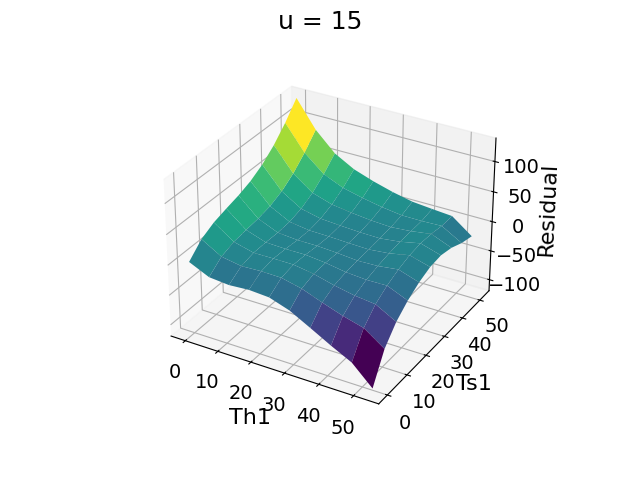

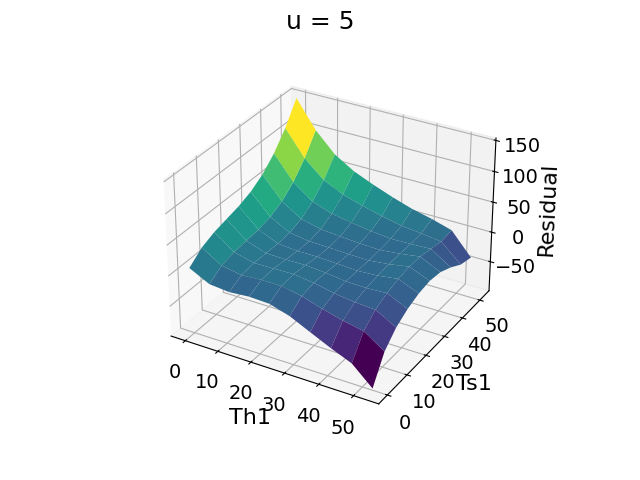

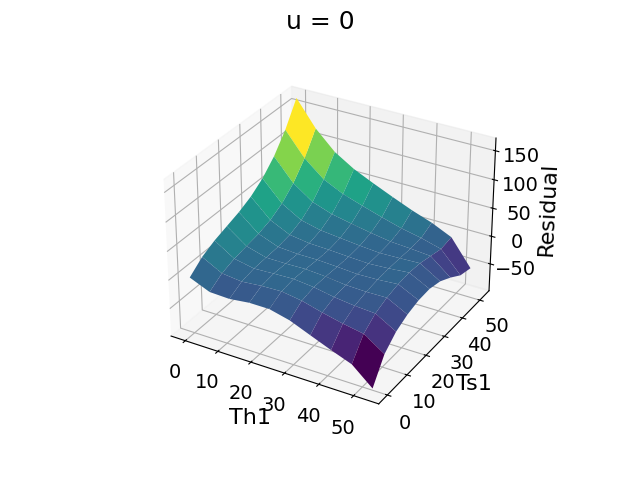

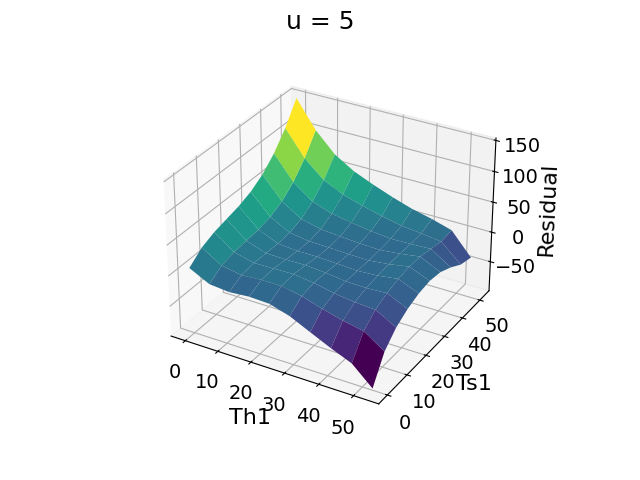

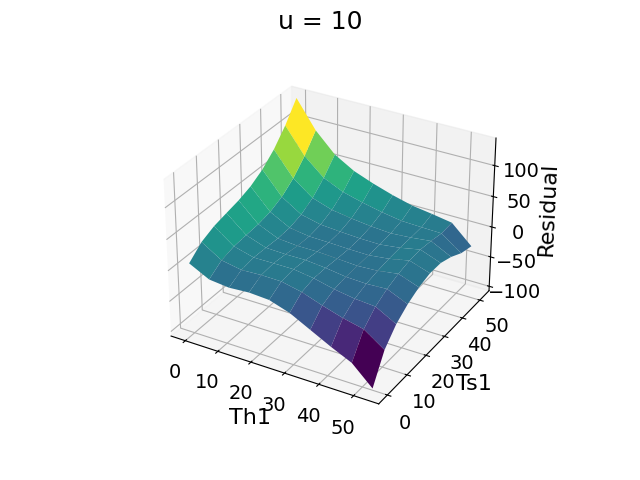

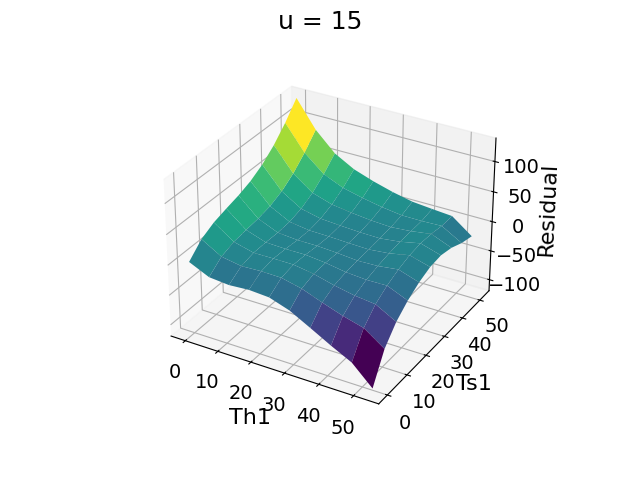

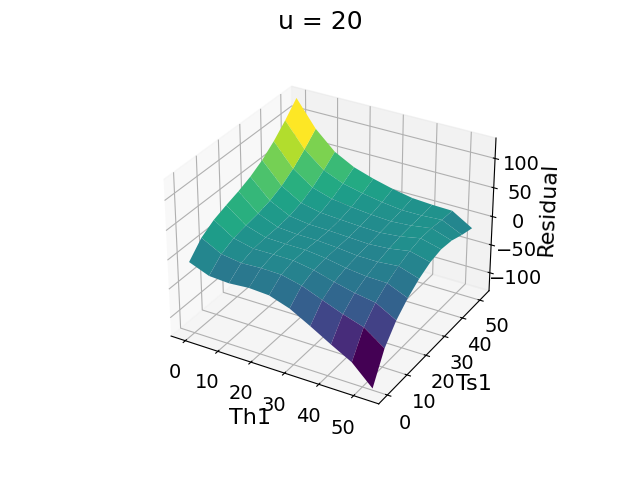

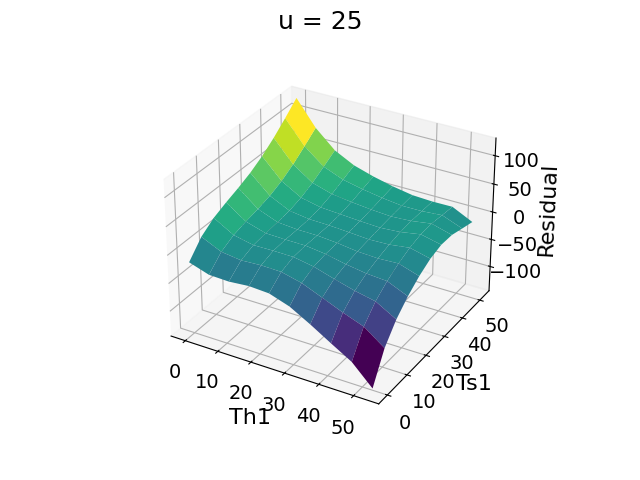

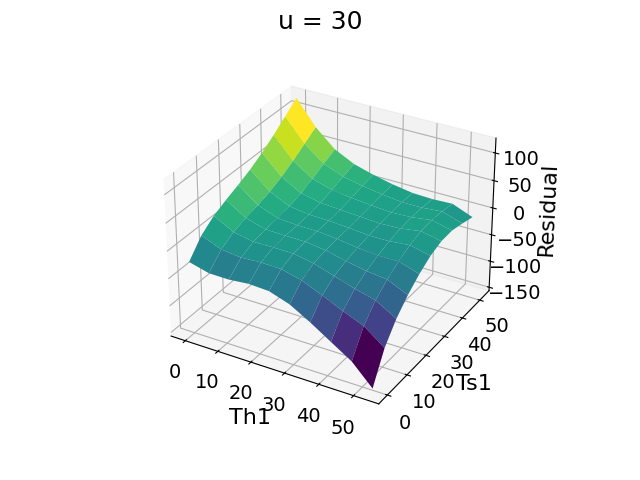

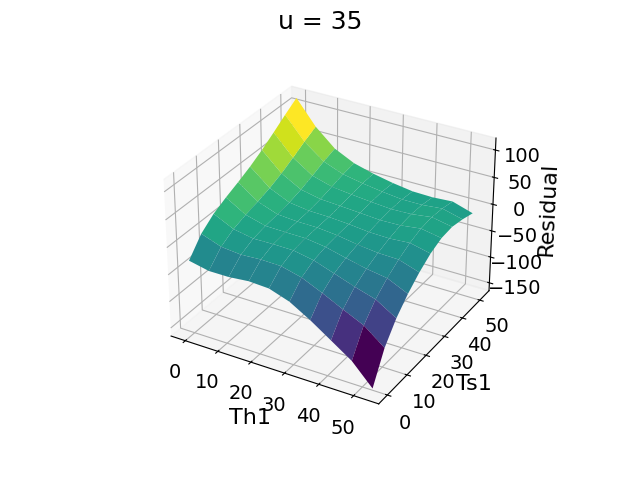

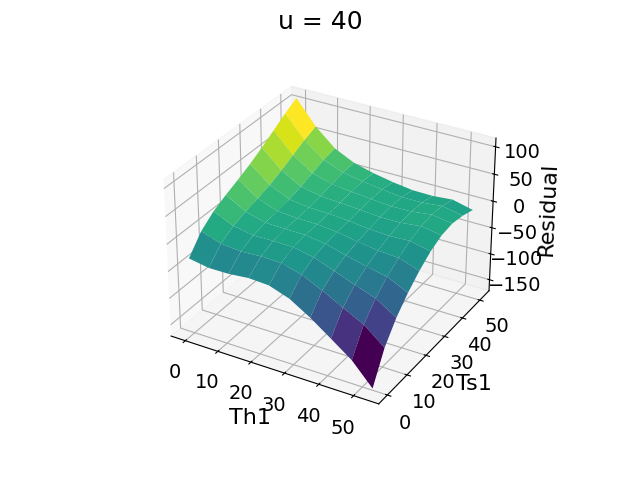

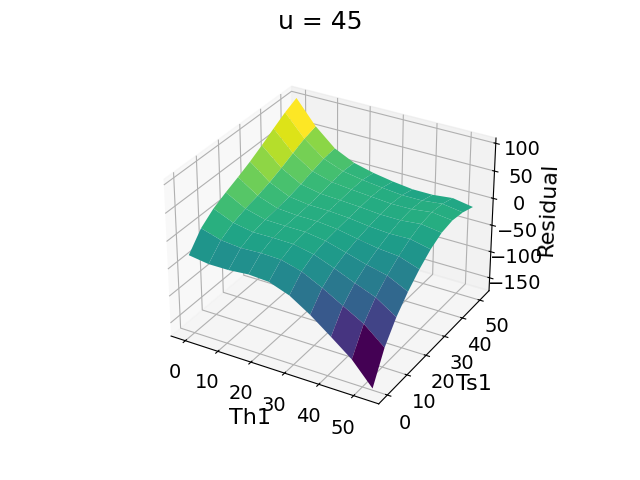

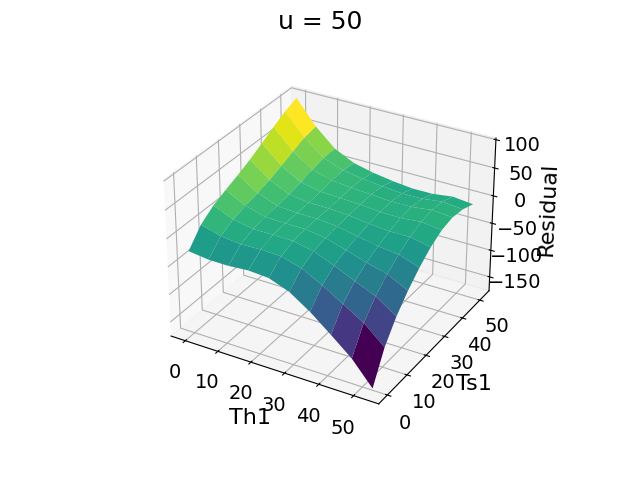

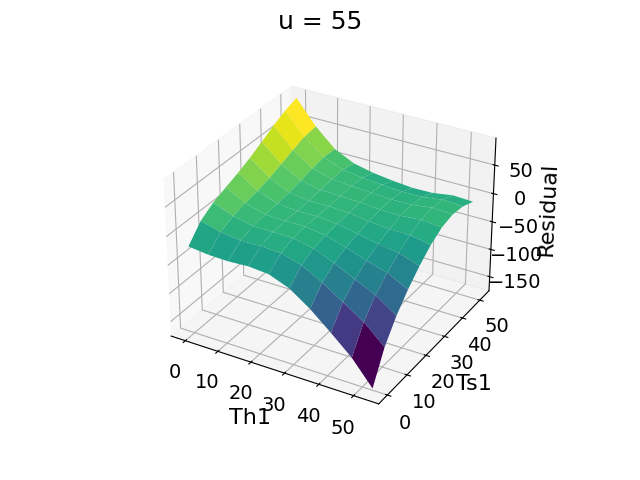

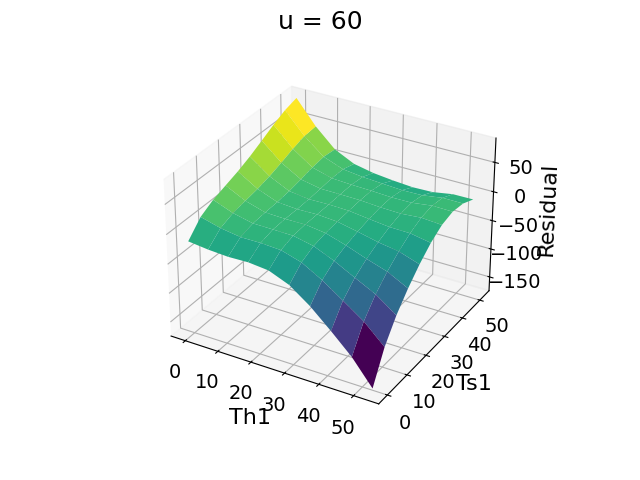

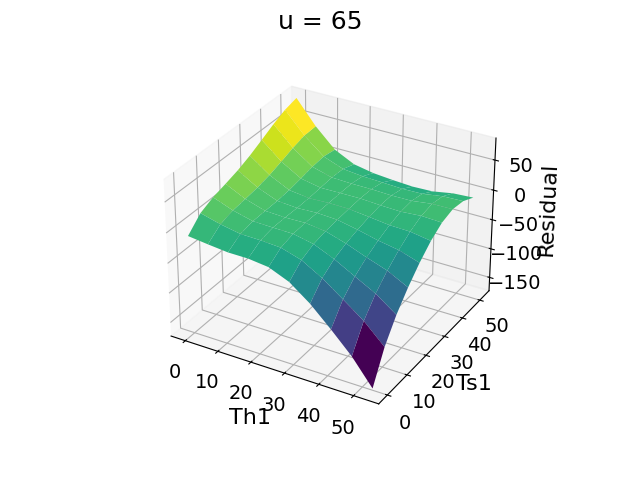

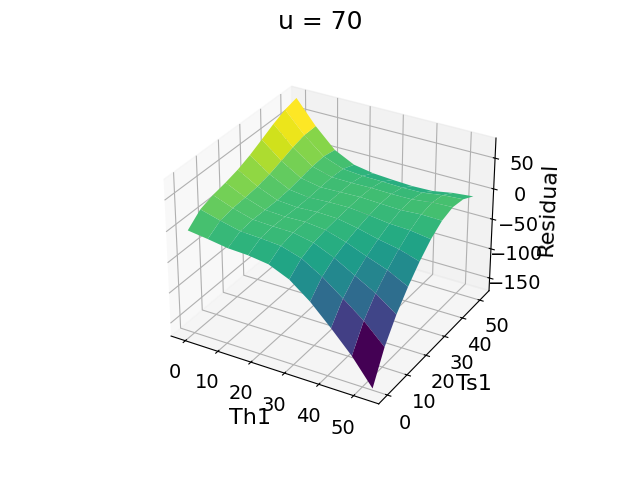

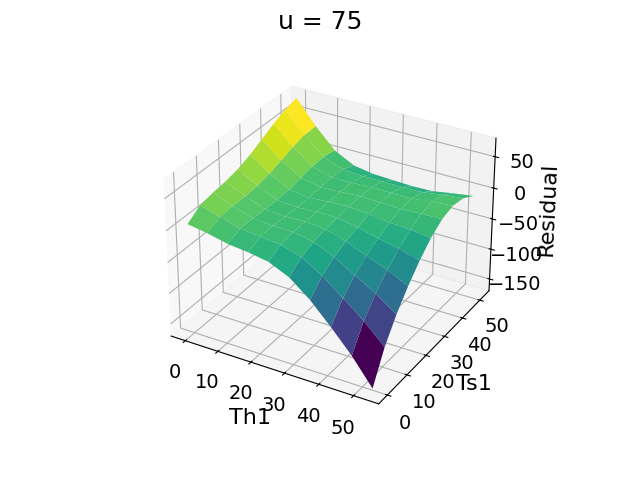

In [28]:
# %matplotlib notebook
%matplotlib widget
from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt


n = 10
n2 = int(n ** 2)
Th1_grid = np.linspace(GP.minmax[0][0], GP.minmax[0][1], n)
Ts1_grid = np.linspace(GP.minmax[1][0], GP.minmax[1][1], n)
Th1_grid, Ts1_grid = np.meshgrid(Th1_grid, Ts1_grid)

def graph(u):
    R_grid = np.reshape(GP.evaluate([Th1_grid.flatten(), Ts1_grid.flatten(), np.repeat(u, n2)], clean=True), [n, n])
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    fig.suptitle(f"u = {u}")
    ax.set_xlabel("Th1")
    ax.set_ylabel("Ts1")
    ax.set_zlabel("Residual")
    ax.plot_surface(Th1_grid, Ts1_grid, R_grid, cmap='viridis')
    fig.show()

interact(graph, u=(0, 100, 5))